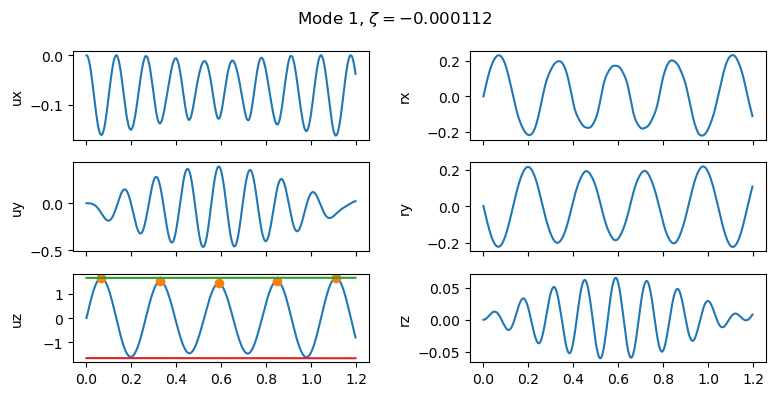

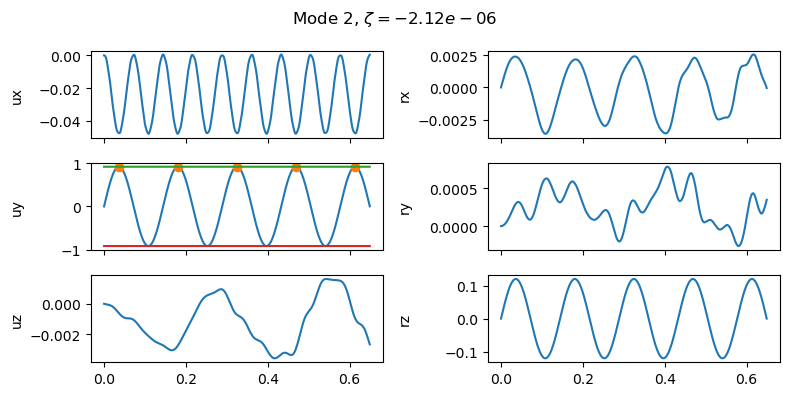

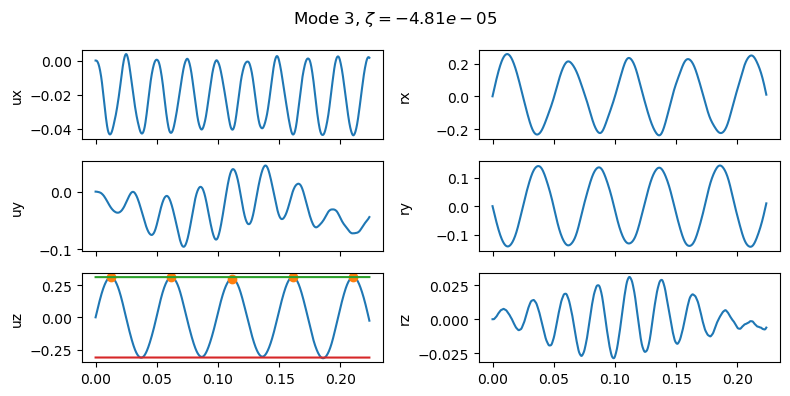

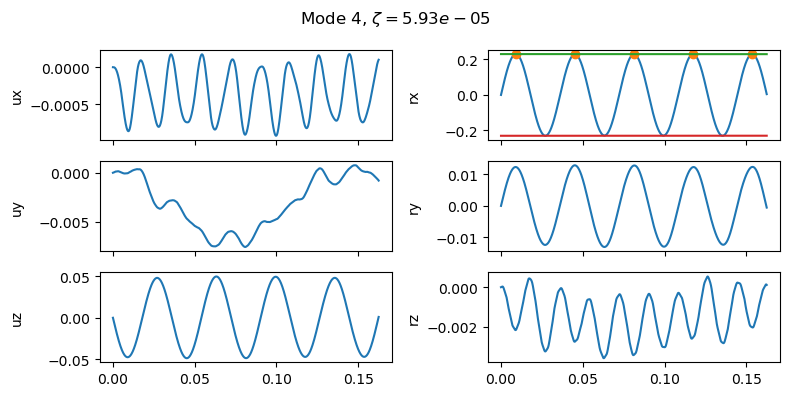

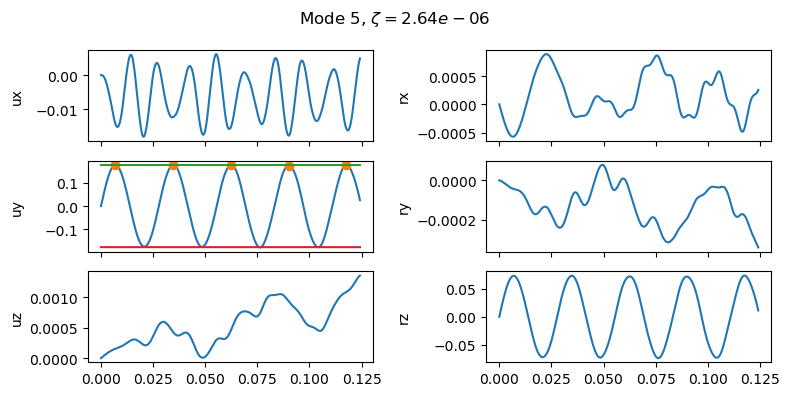

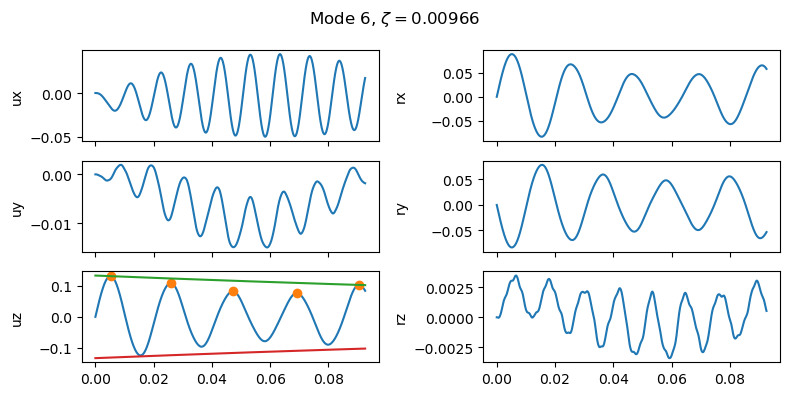

In [13]:
import numpy as np
import matplotlib.pylab as plt
from scipy.signal import find_peaks
import pandas as pd
import glob

def process_file(file_path):

    dat = np.loadtxt(file_path, delimiter=",")

    # Extract time from data
    t = dat[:, 0]

    # Get last node displacement from data
    disp = dat[:,-6:]

    # Find direction containing maximum displacement
    i_dir = np.argmax(np.max(disp, axis=0))

    # Get indices of peak displacement
    i_peaks = find_peaks(disp[:,i_dir])[0]

    # Get time of peak displacements
    t_peaks = t[i_peaks]

    # Calculate oscillation period
    T = np.diff(t_peaks).mean()

    # Get displacement at peaks
    x = disp[i_peaks, i_dir]

    # Calculate number of oscillations
    n = (t_peaks[-1] - t_peaks[0]) / T

    # Calculate log decrement
    dec = np.log(x[0] / x[-1]) / n

    # Calculate damping ratio
    zeta = dec / np.sqrt(4 * np.pi**2 + dec**2)

    # Damped oscillation frequency
    fd = 1 / T

    # Natural frequency
    fn = fd / np.sqrt(1.0 - zeta**2)

    # Calculate starting amplitude of oscillation
    A = x[0] / np.exp(-np.pi * 2 * fn * zeta * t_peaks[0])

    return {
        "T":T,
        "dec": dec,
        "zeta":zeta,
        "fd":fd,
        "fn":fn,
        'omega_n': 2.*np.pi*fn,
        "A":A,
        'dir': i_dir,
    }, t, disp, i_peaks

results = []

dirs = ["ux", "uy", "uz", "rx", "ry", "rz"]

file_paths = sorted(glob.glob("sweep_0*.csv"))

for (mode, f) in enumerate(file_paths,1):

    res, t, disp, i_peaks = process_file(f)
    res['mode'] = mode
    results.append(res)

    fig, ax = plt.subplots(3, 2, figsize=(8, 4), sharex=True)
    fig.suptitle(f'Mode {mode}, $\\zeta={res["zeta"]:.3}$')
    for i, direction in enumerate(["ux", "uy", "uz", "rx", "ry", "rz"]):
        j = 0 if i < 3 else 1
        ax[i%3][j].plot(t, disp[:, i])
        ax[i%3][j].set_ylabel(direction)
        if i == res['dir']:
            ax[i%3][j].plot(t[i_peaks], disp[i_peaks, i], "o")
            y = res["A"] * np.exp(-np.pi * 2 * res["fn"] * res["zeta"] * t)
            ax[i%3][j].plot(t, y)
            ax[i%3][j].plot(t, -y)
    fig.align_ylabels()
    plt.tight_layout()


,T,dec,zeta,fd,fn,omega_n,A,dir,mode
0,0.261000,-0.000702,-0.000112,3.831418,3.831418,24.073507,1.665795,2,1
1,0.144250,-0.000013,-0.000002,6.932409,6.932409,43.557610,0.916728,1,2
2,0.049525,-0.000302,-0.000048,20.191822,20.191822,126.868961,0.311426,2,3
3,0.036150,0.000372,0.000059,27.662517,27.662517,173.808722,0.230148,3,4
4,0.027700,0.000017,0.000003,36.101083,36.101083,226.829794,0.175283,1,5
5,0.021325,0.060697,0.009660,46.893318,46.895506,294.653152,0.132637,2,6
6,0.261000,-0.000702,-0.000112,3.831418,3.831418,24.073507,1.665795,2,1
7,0.144250,-0.000013,-0.000002,6.932409,6.932409,43.557610,0.916728,1,2
8,0.049525,-0.000302,-0.000048,20.191822,20.191822,126.868961,0.311426,2,3
9,0.036150,0.000372,0.000059,27.662517,27.662517,173.808722,0.230148,3,4


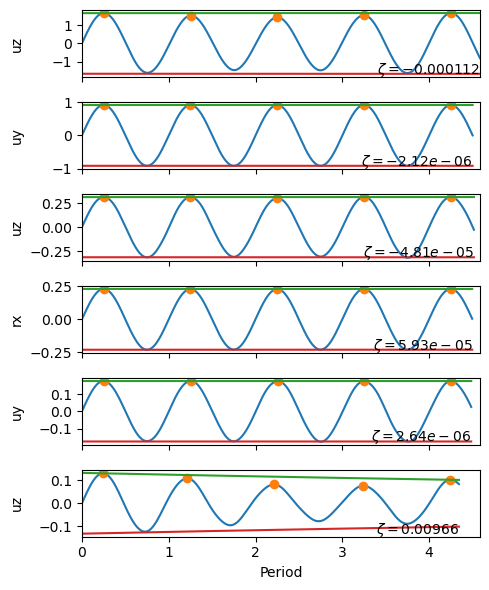

In [14]:
fig, ax = plt.subplots(len(file_paths), figsize=(5,6), sharex=True)

for k, f in enumerate(file_paths):

    res, t, disp, i_peaks = process_file(f)
    res["mode"] = k+1
    results.append(res)

    tp = t*res['fn']

    i = res['dir']
    ax[k].plot(tp, disp[:, i])
    ax[k].set_ylabel(dirs[i])
    ax[k].plot(tp[i_peaks], disp[i_peaks, i], "o")
    y = res["A"] * np.exp(-np.pi * 2 * res["fn"] * res["zeta"] * t)
    ax[k].plot(tp, y)
    ax[k].plot(tp, -y)
    ax[k].text(np.max(tp), np.min(-y), f'$\\zeta={res["zeta"]:.3}$', ha='right')
    ax[k].autoscale(axis='x', tight=True)

ax[-1].set_xlabel('Period')
fig.align_ylabels()
plt.tight_layout()

pd.DataFrame(results)
# # mu = 2 * zeta / (np.pi * 2 * fn)
# # fn, fd, zeta